## Imports and functions

In [1]:
import geopandas as gpd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from shapely.geometry import Polygon, Point, LineString, MultiLineString, mapping
import rasterio
from pyproj import Proj, Geod


In [2]:
def calcSlopeFrom2Pts(x1,y1,x2,y2):
    '''calculate the slope of a line from two points and the strike of that line in degrees from X AXIS
    returns slope, strike'''
    slope = (y2-y1)/(x2-x1)
    strike = np.degrees(np.arctan(slope)) #this is not from NORTH!! this would be from the x-axis (math, not geology)
    return slope, strike

def calcAzimuthFromNorth(x1,y1,x2,y2):
    '''calculate the azimuth (strike) of a line from North using two points'''
    dx = x2 - x1
    dy = y2 - y1

    # make sure dx and dy are not zero. 
    if (dx == 0.0):
        dx = 0.000001
    if (dy == 0.0):
        dy = 0.000001

    #Calculate angle
    angle = np.degrees(np.abs(np.arctan(dy/dx))) #* (180/np.pi)))
    
    #first quadrant
    if (x2>=x1) and (y2>y1):
        azimuth = 90.0 - angle
        # print('first q')
    #second quadrant
    elif (x2>x1) and (y2<=y1):
        azimuth = angle + 90.0
        # print('second q')
    #third quadrant
    elif (x2<=x1) and (y2<y1):
        azimuth = 270.0 - angle
        # print('third q')
    #fourth quadrant
    else:
        azimuth = 270.0 + angle
        # print('fourth q')

    return azimuth


def calcPerpProfile(orig_strike, profile_length, profile_width, center_point): 
    '''calculate a profile perpendicular to a line from a fault strike and a center point.
    return the profile_line as LineString and profile_swath as Polygon
    orig_strike of fault in degrees
    profile_length in meters = TOTAL length
    profile_width in meters = TOTAL width
    center_point as (x1,y1)
    returns profile_line, profile_swath'''
    
    from shapely.geometry import Point, LineString, Polygon
    
    profile_strike = orig_strike + 90
    profile_angle = np.radians(profile_strike)
    
    # calc perp_line start point, profile_length/2 away from center point
    x = center_point[0] + (profile_length/2) * np.cos(profile_angle)
    y = center_point[1] + (profile_length/2) * np.sin(profile_angle)
    startpt = Point(x,y)
    
    # calc perp_line end point, profile_length/2 away from center point
    x = center_point[0] - (profile_length/2) * np.cos(profile_angle)
    y = center_point[1] - (profile_length/2) * np.sin(profile_angle)
    endpt = Point(x,y)
    
    profile_line = LineString([startpt,endpt])
    profile_swath = profile_line.buffer(profile_width/2,16,cap_style=3)
    return profile_line, profile_swath


def generateProfiles(shapefile_lines_path, profile_length, profile_width, profile_spacing,plot=True,verbose=False,save=False,prefix='all',folder='./'): #save_shp=False):
    '''
    generates profiles perpendicular to lines in a shapefile.
    optionally plots input shapefile lines and output profile swaths. default is plot=True. 
    
    inputs are:
    shapefile_lines_path - path location of the shapefile. shapefile must be lines. best if in a UTM coordinate system.
    profile_length - TOTAL length of the profiles in the same units as the shapefile coordinate system (i.e., m if in UTM)
    profile_width - TOTAL width of the profiles in the same units as the shapefile coordinate system (i.e., m if in UTM)
    profile_spacing - distance between each profile in the same units as the shapefile coordinate system (i.e., m if in UTM)
    
    outputs are:
    profile_swaths = geopandas geodataframe of POLYGON features, the profile swath.
    profile_lines = geopandas geodataframe of LINE features, the centerline of each profile perpendicular to the shapefile lines.
    profile_centerpts = geopandas geodataframe of POINT features, the midpoint of each profile line along the shapefile lines.
    
    exports:
    swaths, profiles, centerpts in geoJSON format
    strikes, n_profiles in np format
    
    '''
    
    print('profiles are',profile_width,'m wide,',profile_length,'m long, and',profile_spacing,'m apart')
    
    # read in shapefile lines
    lines = gpd.read_file(shapefile_lines_path)
    # Currently, index_parts defaults to True, but in the future, it will default to False to be consistent with Pandas. Use `index_parts=True` to keep the current behavior and True/False to silence the warning.
    lines = lines.explode(index_parts=True) # this turns multipart lines into single part lines so that profiles remain perpendicular to each line segment if it changes strike...but often doesn't work in Python and might need to do in QGIS first and use the exploded lines shapefile as input file
    lines = lines.reset_index(drop=True) # reset the index because we just added a bunch of lines
    print('CRS of shapefile:', lines.crs)
    
    # initialize geodataframes to hold ALL swath, profile, center_pt, strike info
    ## starting with empty dataframes because we don't know the total size yet
    # this throws a filterwarning that i'm ignoring that you can't initialize a gdf without a CRS...will need to fix eventually
    all_swaths = gpd.GeoDataFrame(geometry=[], crs=lines.crs)#geometry=gpd.points_from_xy(x,y)) # where x and y = np.zeros(len(lines))...but if start this way will have a bunch of nonesense/empty lines to remove later, but it didn't like it when I tried to start with one point
    all_profiles = gpd.GeoDataFrame(geometry=[], crs=lines.crs)#geometry=gpd.points_from_xy(x,y))
    all_centerpts = gpd.GeoDataFrame(geometry=[], crs=lines.crs)#geometry=gpd.points_from_xy(x,y))
    all_strikes = np.ones(len(lines),dtype=float)
    all_swath_strikes = np.array([],dtype=float)
    n_profiles= np.ones(len(lines),dtype=int)
    all_azimuths = np.ones(len(lines),dtype=float)
    
    for i, row in lines.iterrows():
        line_geom = row.geometry
        coords = list(line_geom.coords)
    
        # initialize per-line storage
        swaths_list = []
        profiles_list = []
        centerpts_list = []
        strikes_list = []
        azimuths_list = []
    
        for j in range(len(coords) - 1):
            x1, y1 = coords[j]
            x2, y2 = coords[j + 1]
            seg_length = np.sqrt((x2 - x1)**2 + (y2 - y1)**2)
            if seg_length == 0:
                continue
            
            dx = (x2 - x1) / seg_length
            dy = (y2 - y1) / seg_length
            
            # Ensure at least one profile, even on short segments
            if seg_length < profile_spacing:
                dists = [seg_length / 2]
            else:
                dists = np.arange(profile_spacing / 2, seg_length, profile_spacing)
            
            for dist_along in dists:
                cx = x1 + dx * dist_along
                cy = y1 + dy * dist_along
            
                slope, strike = calcSlopeFrom2Pts(x1, y1, x2, y2)
                azimuth = calcAzimuthFromNorth(x1, y1, x2, y2)
            
                profile_line, profile_swath = calcPerpProfile(strike, profile_length, profile_width, (cx, cy))
            
                swaths_list.append(profile_swath)
                profiles_list.append(profile_line)
                centerpts_list.append(Point(cx, cy))
                strikes_list.append(strike)
                azimuths_list.append(azimuth)


    
        # convert lists to GeoDataFrames
        swaths = gpd.GeoDataFrame(geometry=swaths_list, crs=lines.crs)
        profiles = gpd.GeoDataFrame(geometry=profiles_list, crs=lines.crs)
        center_points = gpd.GeoDataFrame(geometry=centerpts_list, crs=lines.crs)
        center_points['fault_azimuth'] = azimuths_list  # last segment azimuth; optional: store full list
    
        all_swaths = pd.concat([all_swaths, swaths])
        all_profiles = pd.concat([all_profiles, profiles])
        all_centerpts = pd.concat([all_centerpts, center_points])
        all_swath_strikes = np.concatenate([all_swath_strikes, np.array(strikes_list)])
        all_strikes[i] = np.mean(strikes_list)
        all_azimuths[i] = np.mean(azimuths_list)
        n_profiles[i] = len(strikes_list)
    
        # reset index because otherwise the index is duplicated for each line in the shapefile
        all_swaths = all_swaths.reset_index(drop=True)
        all_profiles = all_profiles.reset_index(drop=True)
        all_centerpts = all_centerpts.reset_index(drop=True)
    
        # ensure profiles have same CRS as input shapefile
        all_swaths = all_swaths.set_crs(lines.crs)
        all_profiles = all_profiles.set_crs(lines.crs)
        all_centerpts = all_centerpts.set_crs(lines.crs)
    
    # to plot or not to plot
    if plot==True:
        fig,ax = plt.subplots(figsize=(8,8))
        all_swaths.plot(ax=ax,alpha=.2,color='k')
        all_profiles.plot(ax=ax,color='k',lw=.5)
        all_centerpts.plot(ax=ax,color='b')
        lines.plot(ax=ax,color='r',lw=.75)
        plt.show()


    if save==True:
        all_swaths.to_file(folder+'%s_swaths_%sprofiles.geojson' %(prefix,sum(n_profiles)), driver='GeoJSON') 
        all_profiles.to_file(folder+'%s_profiles_%sprofiles.geojson' %(prefix,sum(n_profiles)), driver='GeoJSON')  
        all_centerpts.to_file(folder+'%s_centerpts_%sprofiles.geojson' %(prefix,sum(n_profiles)), driver='GeoJSON') 
        np.save(folder+'%s_swath_strikes_%sprofiles.npy' %(prefix,sum(n_profiles)),all_swath_strikes, allow_pickle=True,)
        np.save(folder+'%s_strikes_%sprofiles.npy' %(prefix,sum(n_profiles)),all_strikes,allow_pickle=True,)
        np.save(folder+'%s_azimuths_%sprofiles.npy' %(prefix,sum(n_profiles)),all_azimuths,allow_pickle=True,)
        np.save(folder+'%s_n_profiles_%sprofiles.npy' %(prefix,sum(n_profiles)),n_profiles,allow_pickle=True,)



    return all_swaths, all_swath_strikes, all_profiles, all_centerpts, all_strikes, n_profiles, all_azimuths

def sample_swath(raster, fault_point_x, fault_point_y, fault_az_deg, profile_length, swath_width, resolution):
    lon, lat = P(fault_point_x,
                 fault_point_y, inverse=True)
    
    lon1, lat1, _ = G.fwd(
        lon, lat, fault_az_deg - 90,
        profile_length / 2
    )
    lon2, lat2, _ = G.fwd(
        lon, lat, fault_az_deg + 90,
        profile_length / 2
    )

    tmppts = np.array(
        G.npts(
            lon1=lon1, lat1=lat1,
            lon2=lon2, lat2=lat2,
            npts=profile_length/resolution
        )
    )

    starts = G.fwd(
        tmppts[:, 0], tmppts[:, 1],
        [fault_az_deg] * len(tmppts),
        [swath_width / 2] * len(tmppts)
    )
    ends = G.fwd(
        tmppts[:, 0], tmppts[:, 1],
        [fault_az_deg + 180] * len(tmppts),
        [swath_width / 2] * len(tmppts)
    )

    map_object = np.array(list(map(
        lambda lon1, lat1, lon2, lat2:
        G.npts(lon1, lat1, lon2, lat2, swath_width / resolution),
        starts[0], starts[1], ends[0], ends[1]
    )))

    pts = map_object.reshape(
        len(starts[0]) * int(swath_width / resolution), 2
    )
    pts = P(pts[:, 0], pts[:, 1])
    pts = np.column_stack(pts)

    dist = np.arange(-profile_length / 2,
                     profile_length / 2, resolution)
    dists = np.repeat(dist, int(swath_width / resolution))

    raster_samps = np.array([x for x in raster.sample(pts)])
    raster_samps[raster_samps == -9999] = np.nan
    return raster_samps, pts, dists

def fault_curve_fit_noslope(x, a, b, c, ws):
    '''From Milliner et al., 2021
    The solved parameters include the intercept (a), the total fault displacement (b), 
    the fault location (c), the shear width (ws)'''
    return a+b/2*erf((x-c)/(ws*np.sqrt(2)))

def projectParPerp(ns, ew, az):
    theta = (az)*np.pi/180
    par = ns*np.cos(theta)+ew*np.sin(theta)
    perp = -1*ns*np.sin(theta)+ew*np.cos(theta)
    return par.flatten(), perp.flatten()

## Read in fault trace for regular sampling

In [3]:
# CHANGE THESE
utm_zone = 11

In [12]:
# CHANGE THESE EVERY TIME YOU WANT TO CHANGE YOUR PROFILES
fault_map_path = '/Volumes/ProjectsGarlockCSAF/CSAF_Lidar/GIS/FinalFaultGeomFiles/SimpleFaultTrace.geojson'
save = False
folder = '/Users/chanagan/Downloads/MC2020/'
print('saving profiles to: ',folder)

profile_length = 2000 # in meters, not pixels
pixel_res = 1 # Most WV
profile_width = 10 # In meters 
profile_spacing = 100 #in meters 
prefix = 'MC2020'

saving profiles to:  /Users/chanagan/Downloads/MC2020/


Using matplotlib backend: module://matplotlib_inline.backend_inline
profiles are 10 m wide, 2000 m long, and 100 m apart
CRS of shapefile: EPSG:32610


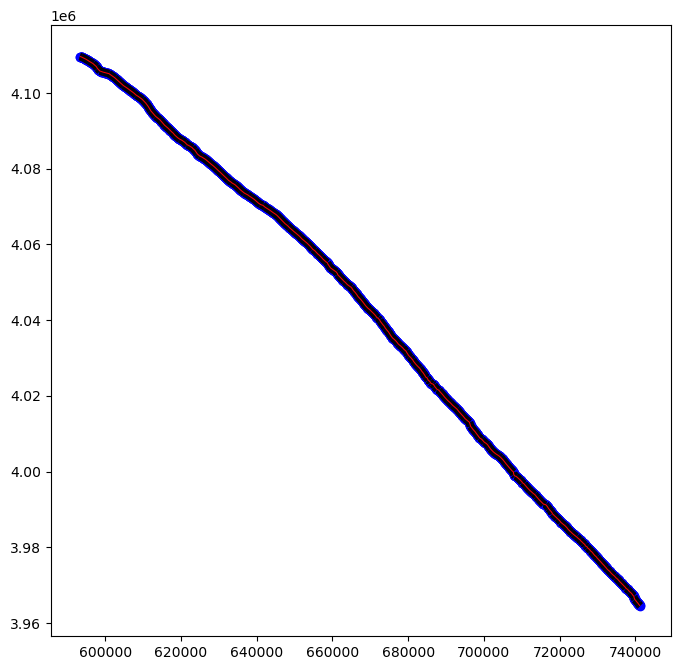

2094 total profiles


In [13]:
%matplotlib
# We only need the center points and swath strikes, so save is disabled but you can enable it for new geojson file creation to the save folder
P = Proj('epsg:326'+str(utm_zone))
G = Geod(ellps='WGS84')

fault_map = gpd.read_file(fault_map_path) # complete representation of faulting to plot
swaths, swath_strikes, profiles, center_points, strikes, n_profs, azimuths = generateProfiles(fault_map_path,profile_length,profile_width,profile_spacing,save=save,prefix=prefix,folder=folder)

print(len(swaths), 'total profiles')

## Parallel and perpendicular profile creation and projection

In [14]:
# CHANGE THESE NAMES AND PATHS
data_type = 'Optical'

ns_path = '/Volumes/ProjectsGarlockCSAF/CSAF_Lidar/MicmacAreaResults/SsResolOpt1/MaskedResults/Velocities/NS_velocity_merged1m.tif'
ew_path = '/Volumes/ProjectsGarlockCSAF/CSAF_Lidar/MicmacAreaResults/SsResolOpt1/MaskedResults/Velocities/EW_velocity_merged1m.tif'

plot = True # faster without plotting. 

In [15]:
# Take a look at the columns of center points. 
# The next cell will create a file for each point. 
# If you don't want all of the profiles, change points in the next code block. 
center_points

,geometry,fault_azimuth
0,POINT (741205.384 3964579.503),312.914383
1,POINT (741132.147 3964647.594),312.914383
2,POINT (741083.197 3964703.383),321.573921
3,POINT (741021.046 3964781.724),321.573921
4,POINT (740985.246 3964824.55),319.935673
...,...,...
2089,POINT (593712.72 4109499.729),296.775141
2090,POINT (593634.923 4109530.312),287.865708
2091,POINT (593539.745 4109560.99),287.865708
2092,POINT (593444.567 4109591.669),287.865708


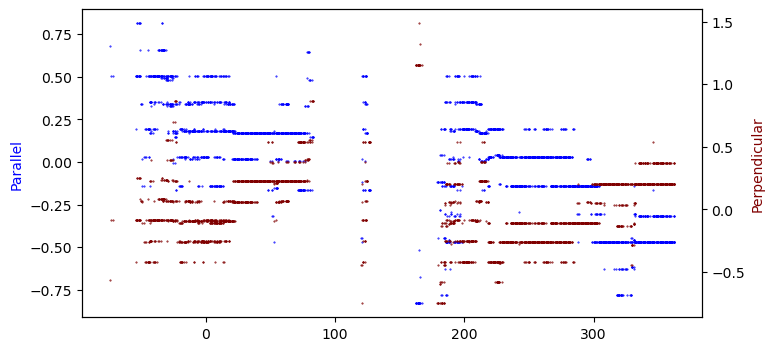

Saving profile fits to: /Users/chanagan/Downloads/MC2020/MC2020_Profile0_SampleSpacing1_ProfLen2000_SwathWidth10_Optical.csv


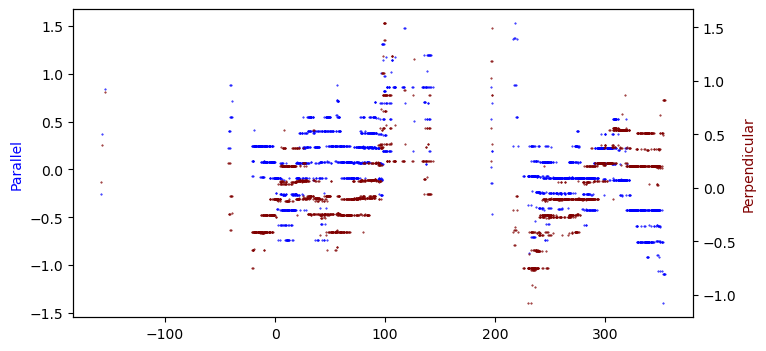

Saving profile fits to: /Users/chanagan/Downloads/MC2020/MC2020_Profile1_SampleSpacing1_ProfLen2000_SwathWidth10_Optical.csv


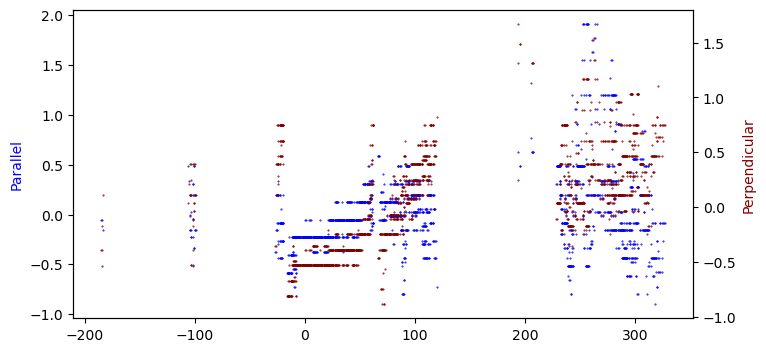

Saving profile fits to: /Users/chanagan/Downloads/MC2020/MC2020_Profile2_SampleSpacing1_ProfLen2000_SwathWidth10_Optical.csv


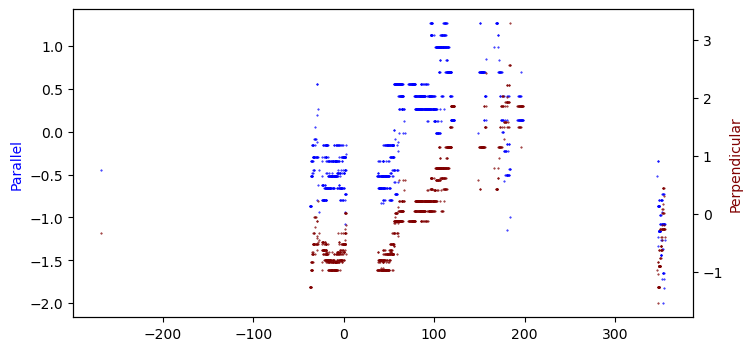

Saving profile fits to: /Users/chanagan/Downloads/MC2020/MC2020_Profile3_SampleSpacing1_ProfLen2000_SwathWidth10_Optical.csv


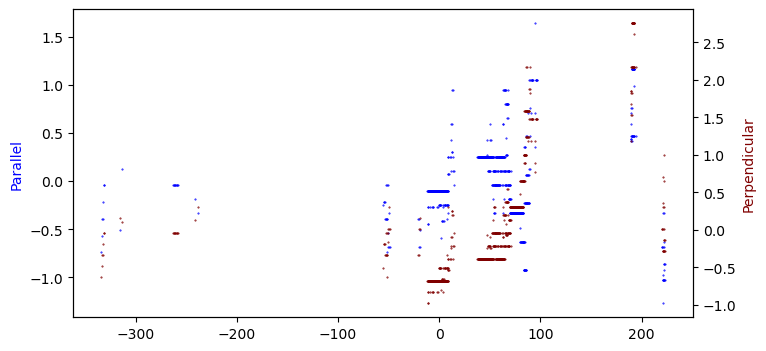

Saving profile fits to: /Users/chanagan/Downloads/MC2020/MC2020_Profile4_SampleSpacing1_ProfLen2000_SwathWidth10_Optical.csv


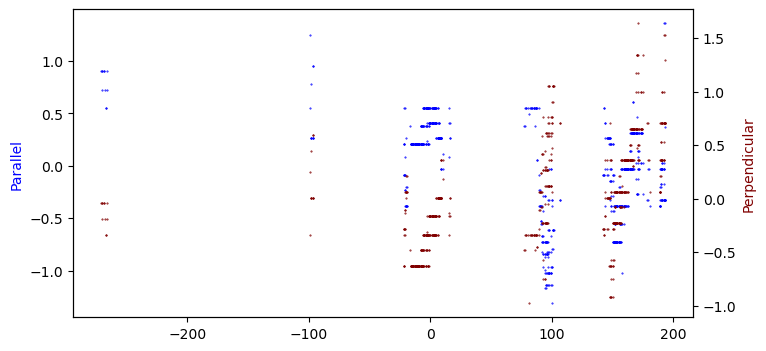

Saving profile fits to: /Users/chanagan/Downloads/MC2020/MC2020_Profile5_SampleSpacing1_ProfLen2000_SwathWidth10_Optical.csv


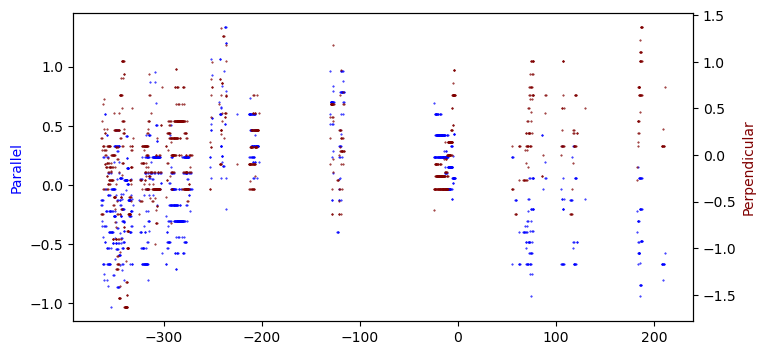

Saving profile fits to: /Users/chanagan/Downloads/MC2020/MC2020_Profile6_SampleSpacing1_ProfLen2000_SwathWidth10_Optical.csv


KeyboardInterrupt: 

In [20]:
# Creates a text file for each profile centered about the profile points
# With parallel and perpendicular diaplcement projection
# Sample rasters, save profile results to separate files
# Note that you can set points to whatever, as long as it has the same column names (geometry with xy position and fault_azimuth)
# the variables par and perp are displacement of each pixel
# while pts corresponds to the xy locations of the pixels 
# dists is the distance of each pixel along the profile. 

points = center_points

ns = rasterio.open(ns_path,masked=True)
ew = rasterio.open(ew_path,masked=True)

# loop through center points along fault 
# each profile has one defined center
for i in np.arange(0, len(points)):
    ns_samps, pts, dists = sample_swath(ns, points.geometry.x.iloc[i], points.geometry.y.iloc[i],
                            points.fault_azimuth.iloc[i], profile_length, profile_width, pixel_res)
    ns_samps[ns_samps == -9999] = np.nan

    ew_samps, pts, dists = sample_swath(ew, points.geometry.x.iloc[i], points.geometry.y.iloc[i],
                            points.fault_azimuth.iloc[i], profile_length, profile_width, pixel_res)
    ew_samps[ew_samps == -9999] = np.nan

    par, perp = projectParPerp(
        ns_samps - np.nanmean(ns_samps),
        ew_samps - np.nanmean(ew_samps),
        points.fault_azimuth.iloc[i]
    )

    if plot is True:
        plt.figure(figsize=(8,4))
        plt.scatter(dists,par,s=0.2,color='blue')
        plt.ylabel('Parallel',color='blue')
        plt.twinx()
        plt.scatter(dists,perp,s=0.2,color='maroon')
        plt.ylabel('Perpendicular',color='maroon')
        plt.xlabel('Profile Distance')
        plt.show()

    fname = f'{folder}{prefix}_Profile{i}_SampleSpacing{pixel_res}_ProfLen{profile_length}_SwathWidth{profile_width}_{data_type}.csv'
    print(f'Saving profile fits to: {fname}')
    tdf = pd.DataFrame({'Northing':pts[:,1],
                    'Easting':pts[:,0],
                    'Profile Distance':dists,
                    'dN':ns_samps.flatten(), 
                     'dE':ew_samps.flatten(), 
                     f'dPar toward {round(points.fault_azimuth.iloc[i])}':par.flatten(), 
                     f'dPerp toward{round(points.fault_azimuth.iloc[i]+90)}':perp.flatten()})

    tdf.to_csv(fname,float_format='%.4f',index=False)

# More general sampling

No projection

In [ ]:
# CHANGE THESE PATHS AND NAMES OF FILE COLUMNS AND DATA TYPE
data_type = 'SAR'

raster1_path = 'UD.tif'
disp_dir1 = 'UD' # displacement direction of raster 1

raster2_path = 'EW.tif'
disp_dir2 = 'EW' # displacement direction of raster 2



In [ ]:
# CREATES A PROFILE FOR EACH CENTER POINT
# Sample rasters, save profile results to separate files
# Note that you can set points to whatever, as long as it has the same column names (geometry with xy position and fault azimuth)
# while pts corresponds to the xy locations of the pixels 
# dists is the distance of each pixel along the profile. 

points = center_points

raster1 = rasterio.open(raster1_path,masked=True)
raster2 = rasterio.open(raster2_path,masked=True)

# loop through center points along fault 
# each profile has one defined center
for i in np.arange(0, len(points)):
    r1_samps, pts, dists = sample_swath(raster1, points.geometry.x.iloc[i], points.geometry.y.iloc[i],
                            points.fault_azimuth.iloc[i], profile_length, profile_width, pixel_res)
    r2_samps[r1_samps == -9999] = np.nan

    r2_samps, pts, dists = sample_swath(raster2, points.geometry.x.iloc[i], points.geometry.y.iloc[i],
                            points.fault_azimuth.iloc[i], profile_length, profile_width, pixel_res)
    r2_samps[r2_samps == -9999] = np.nan


    fname = f'{folder}{prefix}_Profile{i}_SampleSpacing{pixel_res}_ProfLen{profile_length}_SwathWidth{profile_width}_{data_type}.csv'
    print(f'Saving profile fits to: {fname}')
    tdf = pd.DataFrame({'Northing':pts[:,1],
                    'Easting':pts[:,0],
                    'Profile Distance':dists.flatten(),
                     f'd{disp_dir1}':r1_samps.flatten(), 
                     f'd{disp_dir2}':r2_samps.flatten()})

    tdf.to_csv(fname,float_format='%.4f',index=False)